In [1]:
# 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
# 2: Load All CSV Files
customers = pd.read_csv("olist_customers_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")
geolocation = pd.read_csv("olist_geolocation_dataset.csv")
translation = pd.read_csv("product_category_name_translation.csv")

In [5]:
# 3: Data Inspection
# dimensions:
customers.shape
orders.shape
order_items.shape
# columns:
customers.columns
orders.columns
# data types:
customers.info()
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4

In [6]:
# 4: Missing Value Analysis
customers.isnull().sum()
products.isnull().sum()
reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [7]:
# 5: Duplicate Analysis
customers.duplicated().sum()
orders.duplicated().sum()
products.duplicated().sum()

np.int64(0)

In [12]:
# 6: Master Dataset
# Merge Orders + Customers
master = orders.merge(
    customers,
    on='customer_id',
    how='left'
)
# Merge Order Items
master = master.merge(
    order_items,
    on='order_id',
    how='left'
)
# Merge Payments
master = master.merge(
    payments,
    on='order_id',
    how='left'
)
# Merge Reviews
master = master.merge(
    reviews,
    on='order_id',
    how='left'
)
# Merge Products
master = master.merge(
    products,
    on='product_id',
    how='left'
)

In [13]:
# 7: Validate Master Dataset
master.shape
master.head()
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 36 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       119143 non-null  object 
 1   customer_id                    119143 non-null  object 
 2   order_status                   119143 non-null  object 
 3   order_purchase_timestamp       119143 non-null  object 
 4   order_approved_at              118966 non-null  object 
 5   order_delivered_carrier_date   117057 non-null  object 
 6   order_delivered_customer_date  115722 non-null  object 
 7   order_estimated_delivery_date  119143 non-null  object 
 8   customer_unique_id             119143 non-null  object 
 9   customer_zip_code_prefix       119143 non-null  int64  
 10  customer_city                  119143 non-null  object 
 11  customer_state                 119143 non-null  object 
 12  order_item_id                 

In [18]:
# 8: KPI Analysis
# Total Revenue
master['payment_value'].sum()
# Total Orders
master['order_id'].nunique()
# Total Customers
master['customer_id'].nunique()
# Average Order Value
master['payment_value'].sum() / master['order_id'].nunique()
# Average Review Score
master['review_score'].mean()

np.float64(4.015582414978078)

In [20]:
# 9: Customer Analysis
# Top States
master.groupby('customer_state')['customer_id']\
      .nunique()\
      .sort_values(ascending=False)\
      .head(10)
# Top Cities
master.groupby('customer_city')['customer_id']\
      .nunique()\
      .sort_values(ascending=False)\
      .head(10)


customer_city
sao paulo                15540
rio de janeiro            6882
belo horizonte            2773
brasilia                  2131
curitiba                  1521
campinas                  1444
porto alegre              1379
salvador                  1245
guarulhos                 1189
sao bernardo do campo      938
Name: customer_id, dtype: int64

In [22]:
# 10: Product Analysis
# Top Categories by Sales
master['product_category_name']\
      .value_counts()\
      .head(10)
# Revenue by Category
master.groupby('product_category_name')['payment_value']\
      .sum()\
      .sort_values(ascending=False)\
      .head(10)

product_category_name
cama_mesa_banho           1743998.80
beleza_saude              1662963.59
informatica_acessorios    1599481.06
moveis_decoracao          1443963.61
relogios_presentes        1430553.48
esporte_lazer             1400223.07
utilidades_domesticas     1097900.09
automotivo                 855095.68
ferramentas_jardim         840721.59
cool_stuff                 781933.97
Name: payment_value, dtype: float64

In [24]:
# 11: Seller Analysis
# Top Sellers
master.groupby('seller_id')['payment_value']\
      .sum()\
      .sort_values(ascending=False)\
      .head(10)
# Total Sellers
master['seller_id'].nunique()

3095

In [26]:
# 12: Payment Analysis
# Payment Method Usage
master['payment_type'].value_counts()
# Revenue by Payment Type
master.groupby('payment_type')['payment_value']\
      .sum()\
      .sort_values(ascending=False)

payment_type
credit_card    15775450.54
boleto          4110920.74
voucher          435917.84
debit_card       257374.89
not_defined           0.00
Name: payment_value, dtype: float64

In [28]:
# 13: Review Analysis
# Review Distribution
master['review_score'].value_counts()
# Average Revenue by Review Score
master.groupby('review_score')['payment_value']\
      .mean()

review_score
1.0    231.630629
2.0    191.316970
3.0    167.840188
4.0    163.469189
5.0    160.777450
Name: payment_value, dtype: float64

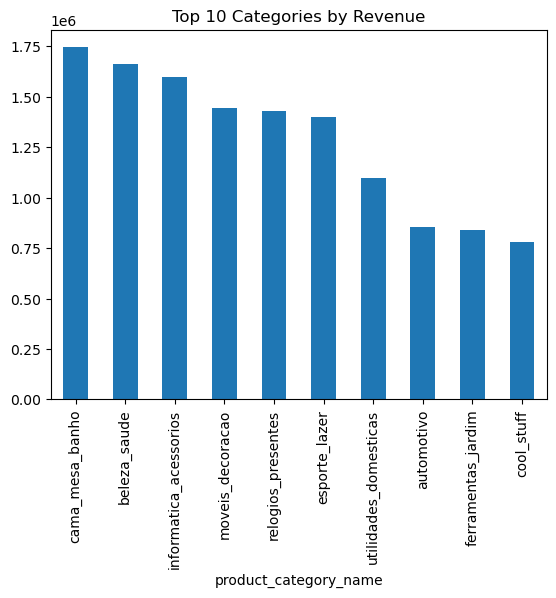

In [29]:
# 14: Visualizations
# Revenue by Category
master.groupby('product_category_name')['payment_value']\
      .sum()\
      .sort_values(ascending=False)\
      .head(10)\
      .plot(kind='bar')

plt.title('Top 10 Categories by Revenue')
plt.show()

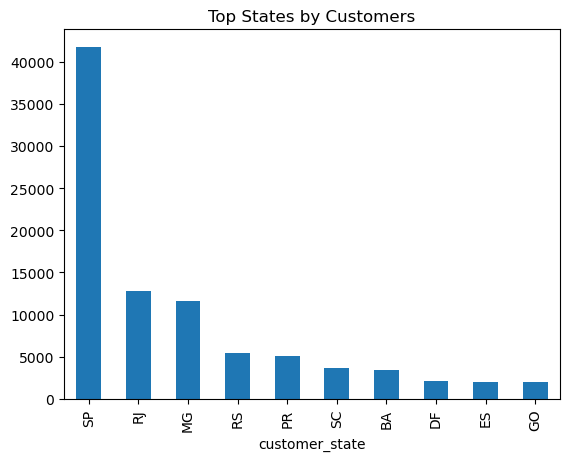

In [30]:
# Top States by Customers
master.groupby('customer_state')['customer_id']\
      .nunique()\
      .sort_values(ascending=False)\
      .head(10)\
      .plot(kind='bar')

plt.title('Top States by Customers')
plt.show()

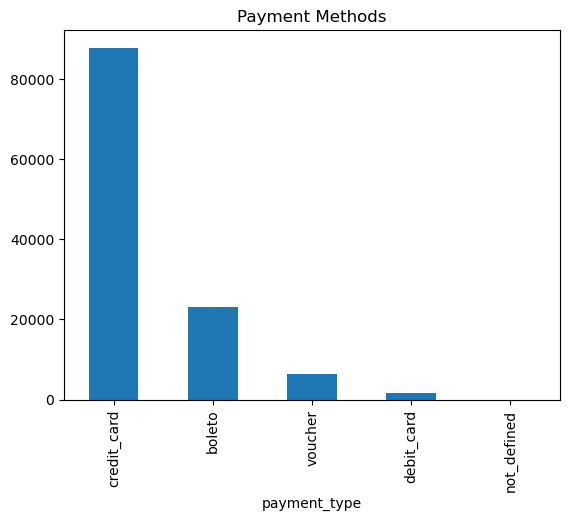

In [31]:
# Payment Methods
master['payment_type']\
      .value_counts()\
      .plot(kind='bar')

plt.title('Payment Methods')
plt.show()

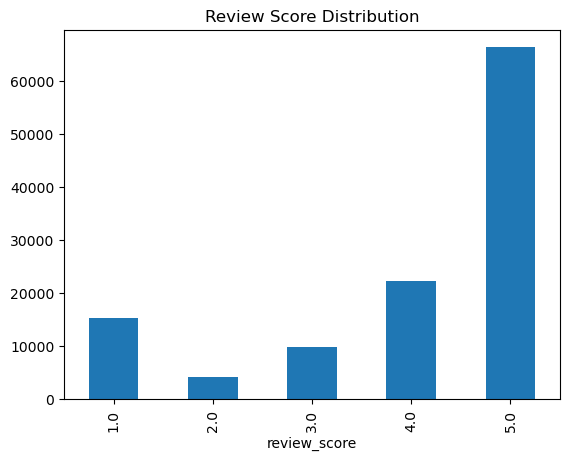

In [32]:
# Review Distribution
master['review_score']\
      .value_counts()\
      .sort_index()\
      .plot(kind='bar')

plt.title('Review Score Distribution')
plt.show()

In [36]:
# 15: BUSINESS INSIGHTS
1. The Quick Commerce platform generated approximately 20.58 million in total revenue.

2. Sao Paulo (SP) is the largest customer and revenue-contributing state.

3. Sao Paulo city represents the most significant customer hub and market.

4. Bed, Bath & Table is the highest-selling and highest-revenue product category.

5. Beauty & Health and Technology categories are also major revenue contributors.

6. Credit Card is the dominant payment method, accounting for the majority of transactions and revenue.

7. The marketplace has a strong customer satisfaction level with an average review score of 4.02.

8. Revenue is concentrated among a small number of top-performing sellers.

9. Major metropolitan cities contribute significantly to overall marketplace performance.

10. High-value customers tend to have higher service expectations, as seen from review analysis.
""")

In [ ]:
# RECOMMENDATIONS
1. Increase marketing investments in Sao Paulo, Rio de Janeiro, and Minas Gerais to maximize customer acquisition.

2. Expand inventory and promotional efforts for high-performing categories such as Bed, Bath & Table, Beauty & Health, and Technology Accessories.

3. Develop seller support and training programs to improve performance among mid-tier sellers.

4. Introduce loyalty programs for high-value customers to improve retention and satisfaction.

5. Continue optimizing the credit-card payment experience, as it is the most preferred payment method.

6. Focus on customer service improvements for premium purchases to reduce negative reviews from high-spending customers.

7. Strengthen logistics and inventory planning in major metropolitan regions where demand is highest.

8. Use customer review analysis to continuously improve product quality and service experience.
""")

In [ ]:
# 16: PROJECT CONCLUSION
The Quick Commerce Business Analytics project successfully analyzed customer behavior, product performance, seller contribution, payment preferences, and customer satisfaction using Python.

The analysis identified key revenue drivers, high-performing product categories, dominant customer markets, and preferred payment methods.

Through data-driven insights and visualizations, the project highlighted opportunities for targeted marketing, inventory optimization, seller development, and customer experience enhancement.

The findings can support strategic decision-making and contribute to improved operational efficiency, customer satisfaction, and revenue growth.
""")

In [ ]:
# 17: Export Final Dataset
master.to_csv(
    r"C:\Users\ayush\OneDrive\Desktop\BA Quick Commerce Project 2\ecommerce_master_python.csv",
    index=False
)